In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Loading
train = pd.read_pickle("../data/train_feature_engineered.pkl")

print(train.shape)

(590540, 432)


In [4]:
# Target and feature
y = train["isFraud"]

X = train.drop(
    columns=["isFraud", "TransactionID"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (590540, 430)
y shape: (590540,)


In [5]:
# Encoding categorical features
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:", len(categorical_cols))

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

Categorical Columns: 31


In [6]:
# Splitting the train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (472432, 430)
X_test: (118108, 430)


In [7]:
# Evaluation function
def evaluate_model(model_name, y_true, y_pred, y_proba):
    print("="*50)
    print(model_name)
    print("="*50)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

In [8]:
# LOgistic Regression
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]

evaluate_model("Logistic Regression", y_test, log_pred, log_proba)

Logistic Regression
Accuracy: 0.6890303789751753
Precision: 0.0741108526929208
Recall: 0.6861843697072345
F1 Score: 0.13377358490566038
ROC-AUC: 0.7537315515949261

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.69      0.81    113975
           1       0.07      0.69      0.13      4133

    accuracy                           0.69    118108
   macro avg       0.53      0.69      0.47    118108
weighted avg       0.95      0.69      0.79    118108



In [11]:
# Storing logidtic regression outcome
model_results = []

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, log_pred),
    "Precision": precision_score(y_test, log_pred),
    "Recall": recall_score(y_test, log_pred),
    "F1": f1_score(y_test, log_pred),
    "ROC_AUC": roc_auc_score(y_test, log_proba)
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.68903,0.074111,0.686184,0.133774,0.753732


In [12]:
# Training Random forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, rf_pred, rf_proba)

Random Forest
Accuracy: 0.8652758492227453
Precision: 0.1740550113453982
Recall: 0.7609484635857731
F1 Score: 0.2833078101071976
ROC-AUC: 0.8889400136830088

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.87      0.93    113975
           1       0.17      0.76      0.28      4133

    accuracy                           0.87    118108
   macro avg       0.58      0.82      0.60    118108
weighted avg       0.96      0.87      0.90    118108



In [ ]:
# Storing Random Forest outcome
model_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf_proba)
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.689030,0.074111,0.686184,0.133774,0.753732
1,Random Forest,0.865276,0.174055,0.760948,0.283308,0.888940


In [14]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba)

XGBoost
Accuracy: 0.98151691672029
Precision: 0.9317980513728964
Recall: 0.5090733123639003
F1 Score: 0.6584259114379596
ROC-AUC: 0.9519502066276564

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.93      0.51      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.75      0.82    118108
weighted avg       0.98      0.98      0.98    118108



In [15]:
# Storing XGBoost outcome
model_results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC_AUC": roc_auc_score(y_test, xgb_proba)
})

results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.689030,0.074111,0.686184,0.133774,0.753732
1,Random Forest,0.865276,0.174055,0.760948,0.283308,0.888940
2,XGBoost,0.981517,0.931798,0.509073,0.658426,0.951950


In [20]:
# Add class weights to XGBoost
scale_pos_weight = (
    y_train.value_counts()[0] / y_train.value_counts()[1]
)

scale_pos_weight

np.float64(27.580278281911674)

In [21]:
xgb_weighted = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(X_train, y_train)

xgb_weighted_pred = xgb_weighted.predict(X_test)
xgb_weighted_proba = xgb_weighted.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost Weighted", y_test, xgb_weighted_pred, xgb_weighted_proba)

XGBoost Weighted
Accuracy: 0.9370406746367731
Precision: 0.33711411381793077
Recall: 0.8270021775949673
F1 Score: 0.4789798206278027
ROC-AUC: 0.9569248321347654

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.94      0.97    113975
           1       0.34      0.83      0.48      4133

    accuracy                           0.94    118108
   macro avg       0.67      0.88      0.72    118108
weighted avg       0.97      0.94      0.95    118108



In [18]:
# Storing Weighted XGBoost outcome
model_results.append({
    "Model": "XGBoost Weighted",
    "Accuracy": accuracy_score(y_test, xgb_weighted_pred),
    "Precision": precision_score(y_test, xgb_weighted_pred),
    "Recall": recall_score(y_test, xgb_weighted_pred),
    "F1": f1_score(y_test, xgb_weighted_pred),
    "ROC_AUC": roc_auc_score(y_test, xgb_weighted_proba)
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.689030,0.074111,0.686184,0.133774,0.753732
1,Random Forest,0.865276,0.174055,0.760948,0.283308,0.888940
2,XGBoost,0.981517,0.931798,0.509073,0.658426,0.951950
3,XGBoost Weighted,0.937041,0.337114,0.827002,0.478980,0.956925


In [19]:
# Threshold tuning for XGBoost
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    pred = (xgb_weighted_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1
0,0.2,0.116758,0.951609,0.207996
1,0.3,0.179267,0.908783,0.299462
2,0.4,0.251777,0.873941,0.390930
3,0.5,0.337114,0.827002,0.478980
4,0.6,0.455621,0.782482,0.575906
5,0.7,0.594977,0.722236,0.652459


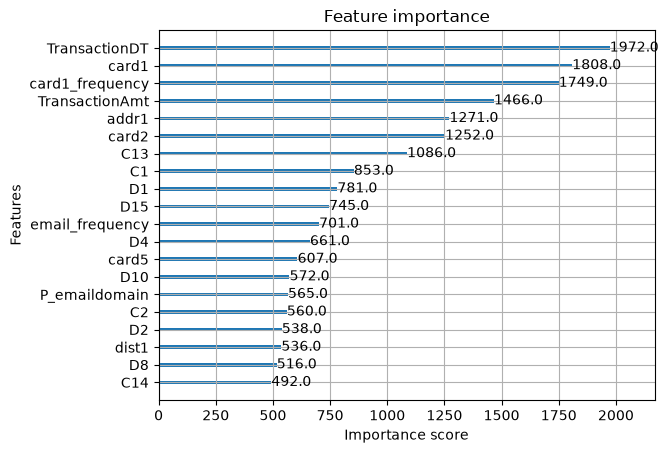

In [22]:
import matplotlib.pyplot as plt

xgb.plot_importance(
    xgb_weighted,
    max_num_features=20
)

plt.show()

In [24]:
import joblib

joblib.dump(
    xgb_weighted,
    "../models/final_xgb_model.pkl"
)

['../models/final_xgb_model.pkl']

In [25]:
import joblib

joblib.dump(
    xgb_weighted,
    "../models/xgb_weighted_model.pkl"
)

['../models/xgb_weighted_model.pkl']

In [10]:
# improving the model with Random Forest
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)